In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
#displaying all the columns
pd.set_option('display.max_columns', None)

In [110]:
supermarket = pd.read_csv('supermarket_sales - Sheet1.csv')
supermarket

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


# About 
The growth of the supermarkets in most populated cities are increasing and market competitions are also high. The dataset is one of the historical sales of supermarket company which has recorded in 3 different branches for 3 months data. Predictive data analytics methods are easy to apply with this dataset.

Attribute information

Invoice id: Computer generated sales slip invoice identification number

Branch: Branch of supercenter (3 branches are available identified by A, B and C).
City: Location of supercenters

Customer type: Type of customers, recorded by Members for customers using member card and Normal for without member card.

Gender: Gender type of customer

Product line: General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel

Unit price: Price of each product in $

Quantity: Number of products purchased by customer

Tax: 5% tax fee for customer buying

Total: Total price including tax

Date: Date of purchase (Record available from January 2019 to March 2019)

Time: Purchase time (10am to 9pm)

Payment: Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)

COGS: Cost of goods sold - the direct costs of producing the goods sold by a company.

Gross margin percentage: In order to calculate it, first subtract the cost of goods sold from the company's revenue. This figure is known as the company's gross profit (as a dollar figure). Then divide that figure by the total revenue and multiply it by 100 to get the gross margin.


Gross income/Total Revenue: total earnings before taxes or other deductions.
Rating: Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)


In [111]:
supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

There are no missing values

In [112]:
supermarket.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [113]:
#Reorder
cols_reorder = ['Invoice ID','Date','Time','Branch','City','Customer type','Gender','Product line', 'Unit price','Quantity',
                'gross income','Tax 5%','Total','Payment','cogs','gross margin percentage', 'Rating']

supermarket = supermarket[cols_reorder]
supermarket.head(2)

,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax 5%,Total,Payment,cogs,gross margin percentage,Rating
0,750-67-8428,1/5/2019,13:08,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,26.1415,548.9715,Ewallet,522.83,4.761905,9.1
1,226-31-3081,3/8/2019,10:29,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,3.8200,80.2200,Cash,76.40,4.761905,9.6


In [114]:
#renaming columns for clarity
supermarket = supermarket.rename(columns = {
    
    'Tax 5%':'Tax(5%)',
    'Total':'Total after tax',
    'Payment': 'Payment method',
    'cogs': 'Cost of goods sold'    
})

supermarket.columns

Index(['Invoice ID', 'Date', 'Time', 'Branch', 'City', 'Customer type',
       'Gender', 'Product line', 'Unit price', 'Quantity', 'gross income',
       'Tax(5%)', 'Total after tax', 'Payment method', 'Cost of goods sold',
       'gross margin percentage', 'Rating'],
      dtype='object')

In [115]:
supermarket.head()

,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax(5%),Total after tax,Payment method,Cost of goods sold,gross margin percentage,Rating
0,750-67-8428,1/5/2019,13:08,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,26.1415,548.9715,Ewallet,522.83,4.761905,9.1
1,226-31-3081,3/8/2019,10:29,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,3.8200,80.2200,Cash,76.40,4.761905,9.6
2,631-41-3108,3/3/2019,13:23,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,16.2155,340.5255,Credit card,324.31,4.761905,7.4
3,123-19-1176,1/27/2019,20:33,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,23.2880,489.0480,Ewallet,465.76,4.761905,8.4
4,373-73-7910,2/8/2019,10:37,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,30.2085,634.3785,Ewallet,604.17,4.761905,5.3


In [116]:
#validating the values
supermarket['Tax(5%)'] = (supermarket['Unit price'] * supermarket['Quantity']) * 0.05
supermarket['Total after tax'] =  (supermarket['Unit price'] * supermarket['Quantity']) + supermarket['Tax(5%)']
supermarket['gross income'] = supermarket['Unit price'] * supermarket['Quantity']


In [117]:
supermarket.head(5)

,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax(5%),Total after tax,Payment method,Cost of goods sold,gross margin percentage,Rating
0,750-67-8428,1/5/2019,13:08,A,Yangon,Member,Female,Health and beauty,74.69,7,522.83,26.1415,548.9715,Ewallet,522.83,4.761905,9.1
1,226-31-3081,3/8/2019,10:29,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,76.40,3.8200,80.2200,Cash,76.40,4.761905,9.6
2,631-41-3108,3/3/2019,13:23,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,324.31,16.2155,340.5255,Credit card,324.31,4.761905,7.4
3,123-19-1176,1/27/2019,20:33,A,Yangon,Member,Male,Health and beauty,58.22,8,465.76,23.2880,489.0480,Ewallet,465.76,4.761905,8.4
4,373-73-7910,2/8/2019,10:37,A,Yangon,Normal,Male,Sports and travel,86.31,7,604.17,30.2085,634.3785,Ewallet,604.17,4.761905,5.3


In [118]:
#removing unnecessary columns
supermarket = supermarket.drop(['Cost of goods sold', 'gross margin percentage'], axis = 1)

In [119]:
supermarket.head(5)

,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax(5%),Total after tax,Payment method,Rating
0,750-67-8428,1/5/2019,13:08,A,Yangon,Member,Female,Health and beauty,74.69,7,522.83,26.1415,548.9715,Ewallet,9.1
1,226-31-3081,3/8/2019,10:29,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,76.40,3.8200,80.2200,Cash,9.6
2,631-41-3108,3/3/2019,13:23,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,324.31,16.2155,340.5255,Credit card,7.4
3,123-19-1176,1/27/2019,20:33,A,Yangon,Member,Male,Health and beauty,58.22,8,465.76,23.2880,489.0480,Ewallet,8.4
4,373-73-7910,2/8/2019,10:37,A,Yangon,Normal,Male,Sports and travel,86.31,7,604.17,30.2085,634.3785,Ewallet,5.3


# Handling duplicates values

In [120]:
#Detecting duplicates values
duplicates = supermarket.duplicated()
supermarket[duplicates]

,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax(5%),Total after tax,Payment method,Rating


There is no duplicated values

# Data types conversion

In [121]:
supermarket.dtypes

Invoice ID          object
Date                object
Time                object
Branch              object
City                object
Customer type       object
Gender              object
Product line        object
Unit price         float64
Quantity             int64
gross income       float64
Tax(5%)            float64
Total after tax    float64
Payment method      object
Rating             float64
dtype: object

In [122]:
supermarket['Date'] = pd.to_datetime(supermarket['Date'])
supermarket['Branch'] = supermarket['Branch'].astype('category')
supermarket['Customer type'] = supermarket['Customer type'].astype('category')
supermarket['Gender'] = supermarket['Gender'].astype('category')
supermarket['Product line'] = supermarket['Product line'].astype('category')
supermarket['Payment method'] = supermarket['Payment method'].astype('category')

In [123]:
supermarket.dtypes

Invoice ID                 object
Date               datetime64[ns]
Time                       object
Branch                   category
City                       object
Customer type            category
Gender                   category
Product line             category
Unit price                float64
Quantity                    int64
gross income              float64
Tax(5%)                   float64
Total after tax           float64
Payment method           category
Rating                    float64
dtype: object

# Missing values

In [124]:
#checking missing values
supermarket.isnull().sum()

Invoice ID         0
Date               0
Time               0
Branch             0
City               0
Customer type      0
Gender             0
Product line       0
Unit price         0
Quantity           0
gross income       0
Tax(5%)            0
Total after tax    0
Payment method     0
Rating             0
dtype: int64

There is no missing values

# Dealing with outliers

<AxesSubplot:>

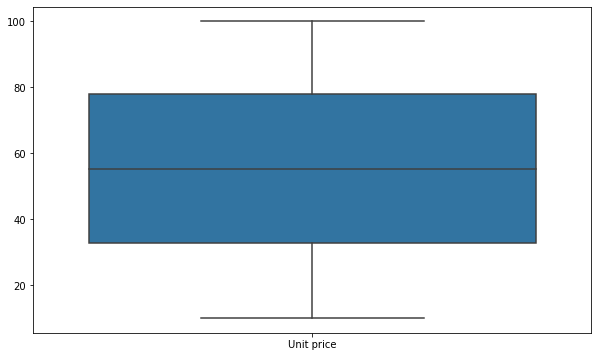

In [125]:
#checking outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=supermarket[['Unit price']])

All data falls within the range, there is no outliers

# Saving cleaned data

In [129]:
supermarket.to_csv("supermarket_cleaned.csv")

In [131]:
pd.read_csv('supermarket_cleaned.csv')

,Unnamed: 0,Invoice ID,Date,Time,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,gross income,Tax(5%),Total after tax,Payment method,Rating
0,0,750-67-8428,2019-01-05,13:08,A,Yangon,Member,Female,Health and beauty,74.69,7,522.83,26.1415,548.9715,Ewallet,9.1
1,1,226-31-3081,2019-03-08,10:29,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,76.40,3.8200,80.2200,Cash,9.6
2,2,631-41-3108,2019-03-03,13:23,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,324.31,16.2155,340.5255,Credit card,7.4
3,3,123-19-1176,2019-01-27,20:33,A,Yangon,Member,Male,Health and beauty,58.22,8,465.76,23.2880,489.0480,Ewallet,8.4
4,4,373-73-7910,2019-02-08,10:37,A,Yangon,Normal,Male,Sports and travel,86.31,7,604.17,30.2085,634.3785,Ewallet,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,233-67-5758,2019-01-29,13:46,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,40.35,2.0175,42.3675,Ewallet,6.2
996,996,303-96-2227,2019-03-02,17:16,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,973.80,48.6900,1022.4900,Ewallet,4.4
997,997,727-02-1313,2019-02-09,13:22,A,Yangon,Member,Male,Food and beverages,31.84,1,31.84,1.5920,33.4320,Cash,7.7
998,998,347-56-2442,2019-02-22,15:33,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,65.82,3.2910,69.1110,Cash,4.1
